# Printout parameters of each neuron in a multi-layer neural network after each epoch

In [72]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Reproducibility
torch.manual_seed(0)

# Dataset: 100 samples, 8 features
X = torch.randn(100, 8)
y = torch.randint(0, 2, (100,))

loader = DataLoader(TensorDataset(X, y), batch_size=16, shuffle=True)

# Model
model = nn.Sequential(
    nn.Linear(8, 4),   # 4 neurons
    nn.ReLU(),
    nn.Linear(4, 2)    # 2 neurons
)


===== Epoch 0 =====

Layer: 0 (8 → 4)


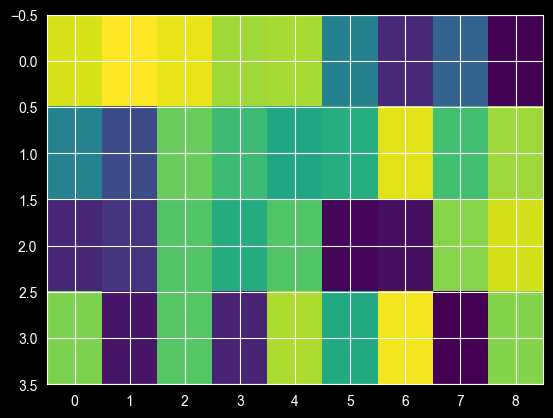


Layer: 2 (4 → 2)


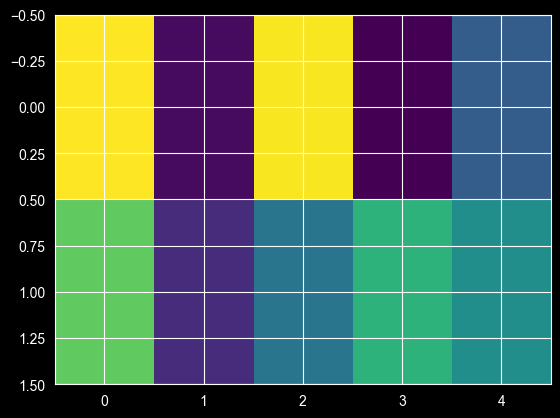

(2, 5)

===== Epoch 1 =====

Layer: 0 (8 → 4)


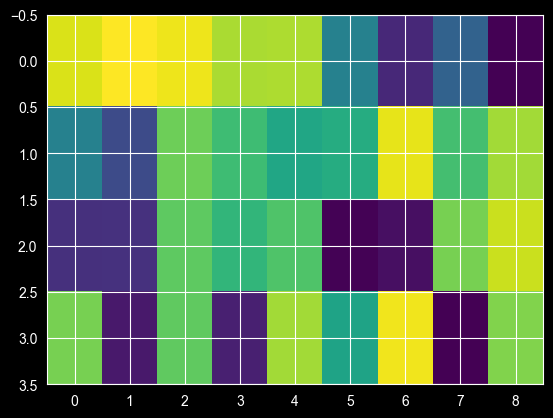


Layer: 2 (4 → 2)


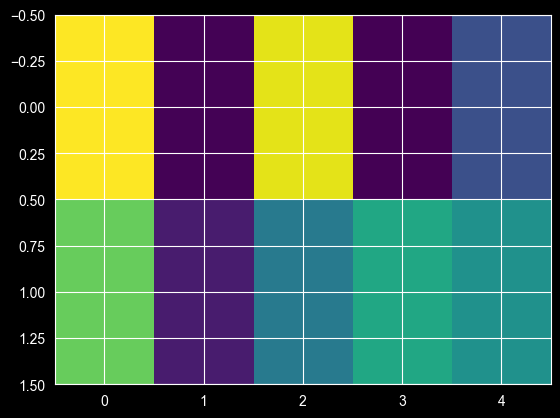

(2, 5)

===== Epoch 2 =====

Layer: 0 (8 → 4)


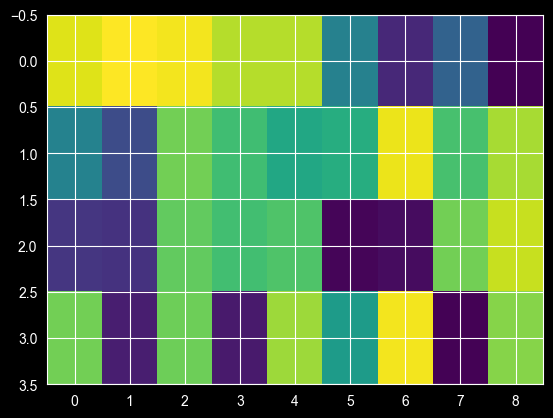


Layer: 2 (4 → 2)


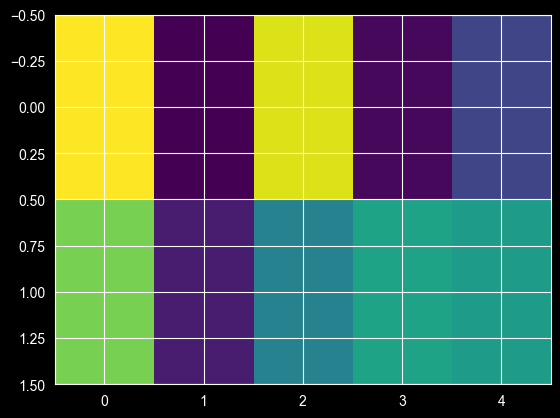

(2, 5)


In [73]:
import numpy as np
import matplotlib.pyplot as plt

def print_linear_params_by_neuron(model, epoch, ):
    print(f"\n===== Epoch {epoch} =====")
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            print(f"\nLayer: {name} ({module.in_features} → {module.out_features})")

            W = module.weight.detach().numpy()  # [out_features, in_features]
            b = module.bias.detach().numpy() if module.bias is not None else None
            # Append bias to weights
            if b is not None:
                Wb = np.hstack([W, b.reshape(-1, 1)])
            else:
                Wb = W
            # print(f"\n{Wb}")
            # print(Wb.size())

            #for i in range(W.size(0)):  # out_features = neurons
            #    print(f"  Neuron {i}:")
            #    print(f"    weights: {W[i].tolist()}")
            #    if b is not None:
            #        print(f"    bias: {b[i].item()}")

            plt.imshow(Wb, cmap='viridis', aspect='auto')
            plt.show()
    return Wb

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

num_epochs = 3

for epoch in range(num_epochs):
    model.train()
    for xb, yb in loader:
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

    # Print neuron parameters AFTER the epoch update
    Wb = print_linear_params_by_neuron(model, epoch)
    print(Wb.shape)  # Should be [out_features, in_features + 1] for the last linear layer



